<a href="https://colab.research.google.com/github/beyzanurkeles/Medical-Imaging-Tumor-Segmentation-Image-Processing-/blob/main/ISPY_nnUNet_v2_en_guncel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# gpu_info = !nvidia-smi
# gpu_info = '\n'.join(gpu_info)
# if gpu_info.find('failed') >= 0:
#   print('Not connected to a GPU')
# else:
#   print(gpu_info)

Çok Net Görüntülerde Attentionlı + DCE BCE Loss + Augmentation Eklenmiş Model (600)

Google Drive’ı bağlama ✅

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Kütüphane kurulumu ✅

Gereksiz/çakışan paketleri kaldırma
(önceden yüklenmiş nnUNet veya mmcv paketleri varsa temizler)

In [ ]:
!pip uninstall -y nnunet nnunetv2 mmcv mmcv-full mmdet openmim || true


pip / wheel / setuptools güncelleme ✅

---



In [ ]:
!pip install --upgrade pip wheel setuptools


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 79.9 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


In [ ]:
# ================================
# 4. nnU-Net için gerekli kütüphaneler (güncel)
# - nibabel: .nii.gz medikal görüntüler
# - batchgeneratorsv2: yeni augmentasyon altyapısı (nnU-Net >= v2.5 ile uyumlu)
# - SimpleITK, scikit-image, scikit-learn: görüntü işleme / preprocess
# - pandas, tqdm, matplotlib: raporlama, loglama
# ================================
!pip install nibabel batchgeneratorsv2 SimpleITK scikit-image scikit-learn pandas tqdm matplotlib


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 50.6 MB/s  0:00:01
  Created wheel for batchgeneratorsv2: filename=batchgeneratorsv2-0.3.0-py3-none-any.whl size=65215 sha256=14a1cb342d1ea705e5f94c683c89ef03ad41145eb37497c1e618373c86d6e93d
  Stored in directory: /root/.cache/pip/wheels/9d/99/a0/1224a58f286be9fedbdb256d41e782a63b5ecab743e92ed302
  Created wheel for batchgenerators: filename=batchgenerators-0.25.1-py3-none-any.whl size=93163 sha256=a3b11291e3dfa04fe41d38c41c0304f7d7a3bfafe4461f23eaa2c45f1c8c2b26
  Stored in directory: /root/.cache/pip/wheels/28/21/2b/7b25080f9f5847e6c3162b89d859d7cec9f3093158e56bd008
Successfully built batchgeneratorsv2 batchgenerators
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/

PyTorch kurulumu

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118


Looking in indexes: https://download.pytorch.org/whl/cu118


Kütüphane Kontrolu

In [ ]:
# Kontrol
import nibabel as nib
print("Nibabel version:", nib.__version__)

import batchgenerators
from batchgenerators.dataloading.multi_threaded_augmenter import MultiThreadedAugmenter

print("Batchgenerators OK ✅")

Nibabel version: 5.3.2
Batchgenerators OK ✅


In [ ]:
import torch
print("Torch version:", torch.__version__)
print("CUDA build     :", torch.version.cuda)
print("CUDA available :", torch.cuda.is_available())
print("GPU count      :", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name       :", torch.cuda.get_device_name(0))

Torch version: 2.9.0+cu126
CUDA build     : 12.6
CUDA available : True
GPU count      : 1
GPU name       : Tesla T4


nnUNet v2 kodunu klonla

In [ ]:
# güvenli köke dön
%cd /content

# varsa eski klasörü temizle (önceki denemelerden kalma olabilir)
!rm -rf /content/nnUNet

# klonla
!git clone https://github.com/MIC-DKFZ/nnUNet.git /content/nnUNet
%cd /content/nnUNet

# 🔴 kritik: pyproject.toml'u geçici olarak pasifleştir (editable install için)
!mv pyproject.toml pyproject.toml.bak

# setup.py tabanlı editable kurulum (build izolasyonunu kapat)
!pip install -e . --no-build-isolation


/content
Cloning into '/content/nnUNet'...
remote: Enumerating objects: 14008, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 14008 (delta 0), reused 0 (delta 0), pack-reused 14006 (from 2)
Receiving objects: 100% (14008/14008), 8.61 MiB | 18.44 MiB/s, done.
Resolving deltas: 100% (10703/10703), done.
/content/nnUNet
Obtaining file:///content/nnUNet
  Checking if build backend supports build_editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for nnunetv2 (pyproject.toml) ... done
  Created wheel for nnunetv2: filename=nnunetv2-0.0.0-0.editable-py3-none-any.whl size=6887 sha256=3e517bffa024e2a9ebe9d55aa1ea99bc88763098997d3293e6772eaff6a15b31
  Stored in directory: /tmp/pip-ephem-wheel-cache-e2z6r18n/wheels/e4/49/54/747a776959ad4bad6675565e9c9011de0787353cf8a2e4683d
Successfully built nnunetv2


In [ ]:
!pip install acvl-utils


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 63.2 MB/s  0:00:00
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)
  Created wheel for acvl-utils: filename=acvl_utils-0.2.5-py3-none-any.whl size=27243 sha256=9c14ce6852b5d40ae9013986853c1d02c4f94edb16bd1088ee3e7e718628d230
  Stored in directory: /root/.cache/pip/wheels/70/c4/16/bae888b32a033f634d91a14256a8f8c8ec97db4e4dad8f0216
Successfully built acvl-utils
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [acvl-utils]


In [ ]:
!pip install dynamic-network-architectures

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for dynamic-network-architectures: filename=dynamic_network_architectures-0.4.2-py3-none-any.whl size=39081 sha256=5d0001683bebbd4d739b2cd83d20b3fb28d9295b33262503b1b6e32b9e67580b
  Stored in directory: /root/.cache/pip/wheels/c2/a8/c5/241ab34db40b3a6f498d2794411cc08a6309fefdc0d6e3d9f3
Successfully built dynamic-network-architectures


In [ ]:
# dynamic-network-architectures yüklenmiş mi
import sys
import pathlib

paths = list(pathlib.Path("/usr").rglob("dynamic_network_architectures"))
paths


[PosixPath('/usr/local/lib/python3.12/dist-packages/dynamic_network_architectures')]

Eski __pycache__ temizle:

In [ ]:
import shutil, os
for root, dirs, files in os.walk("/usr/local/lib/python3.12/dist-packages/dynamic_network_architectures"):
    if "__pycache__" in dirs:
        shutil.rmtree(os.path.join(root, "__pycache__"), ignore_errors=True)


küçük bir test yap

In [ ]:
from dynamic_network_architectures.building_blocks.simple_conv_blocks import (
    ConvDropoutNormReLU, StackedConvBlocks, ChannelAttention, SpatialAttention
)
print("OK →", ConvDropoutNormReLU, StackedConvBlocks)


OK → <class 'dynamic_network_architectures.building_blocks.simple_conv_blocks.ConvDropoutNormReLU'> <class 'dynamic_network_architectures.building_blocks.simple_conv_blocks.StackedConvBlocks'>


In [ ]:
# ============================
#  CBAM Test – Class Import Kontrol
# ============================

print("🔍 CBAM Attention Kontrolü Başlatılıyor...\n")

try:
    from dynamic_network_architectures.building_blocks.simple_conv_blocks import (
        ConvDropoutNormReLU,
        StackedConvBlocks,
        ChannelAttention,
        SpatialAttention
    )

    print("✅ ConvDropoutNormReLU Yüklendi:", ConvDropoutNormReLU)
    print("✅ StackedConvBlocks Yüklendi:", StackedConvBlocks)
    print("✅ ChannelAttention Yüklendi:", ChannelAttention)
    print("✅ SpatialAttention Yüklendi:", SpatialAttention)

    print("\n🎉 TEBRİKLER! Tüm attention blokları başarılı şekilde import edildi.")
    print("🔥 CBAM (Channel + Spatial Attention) şu anda aktif çalışacak.")

except Exception as e:
    print("\n❌ HATA: Attention modülleri import edilemedi!")
    print("🛠️ Hata mesajı:", e)
    print("\nLütfen simple_conv_blocks.py dosyasını tekrar kontrol et.")


🔍 CBAM Attention Kontrolü Başlatılıyor...

✅ ConvDropoutNormReLU Yüklendi: <class 'dynamic_network_architectures.building_blocks.simple_conv_blocks.ConvDropoutNormReLU'>
✅ StackedConvBlocks Yüklendi: <class 'dynamic_network_architectures.building_blocks.simple_conv_blocks.StackedConvBlocks'>
✅ ChannelAttention Yüklendi: <class 'dynamic_network_architectures.building_blocks.simple_conv_blocks.ChannelAttention'>
✅ SpatialAttention Yüklendi: <class 'dynamic_network_architectures.building_blocks.simple_conv_blocks.SpatialAttention'>

🎉 TEBRİKLER! Tüm attention blokları başarılı şekilde import edildi.
🔥 CBAM (Channel + Spatial Attention) şu anda aktif çalışacak.


Dosyalar kısmında görebilmek için çalıştır

In [ ]:
!ln -s /usr/local/lib/python3.12/dist-packages/dynamic_network_architectures /content/dna


In [ ]:
# # Attention eklenmiş mi
# from dynamic_network_architectures.building_blocks.simple_conv_blocks import ConvDropoutNormReLU, ChannelAttention

# print("ConvDropoutNormReLU:", ConvDropoutNormReLU)
# print("ChannelAttention:", ChannelAttention)


ConvDropoutNormReLU: <class 'dynamic_network_architectures.building_blocks.simple_conv_blocks.ConvDropoutNormReLU'>
ChannelAttention: <class 'dynamic_network_architectures.building_blocks.simple_conv_blocks.ChannelAttention'>


HYBRID LOSS DOSYASI

Dosyanın eklenmesi gereken yer:                                                      /content/nnUNet/nnunetv2/training/loss/hybrid_loss.py

Dosya adı: hybrid_loss.py

In [ ]:
# Dosya Yüklenmiş mi Kontrol
!grep -n "DiceBCELoss" /content/nnUNet/nnunetv2/training/loss/hybrid_loss.py

Kontrol

In [ ]:
from nnunetv2.training.loss.hybrid_loss import HybridLoss

loss_fn = HybridLoss()
print(loss_fn)


HybridLoss(
  (dice): SoftDiceLoss()
  (bce): BCEWithLogitsLoss()
  (focal): FocalLoss()
)


Dice + BCE kombinasyonu ekleme (Dosyanın eklenmesi gereken yer:                                                      /content/nnUNet/nnunetv2/training/loss/dice_bce_loss.py)

In [ ]:
# # Dosya Yüklenmiş mi Kontrol
# !grep -n "DiceBCELoss" /content/nnUNet/nnunetv2/training/loss/dice_bce_loss.py

In [ ]:
# Loss fonksiyonunun nnUNet tarafından gerçekten import edilebildi mi?
# Çıktı bu olmalı:
# DiceBCELoss(
#   (bce): BCEWithLogitsLoss()
# )

from nnunetv2.training.loss.dice_bce_loss import DiceBCELoss

loss_fn = DiceBCELoss()
print(loss_fn)


DiceBCELoss(
  (bce): BCEWithLogitsLoss()
)


In [ ]:
# import re

# file_path = "/content/nnUNet/nnunetv2/training/loss/dice_bce_loss.py"

# # Dosyayı oku
# with open(file_path, "r", encoding="utf-8") as f:
#     txt = f.read()

# # U+00A0 olan görünmez karakterleri NORMAL boşluk ile değiştir
# cleaned = txt.replace('\u00A0', ' ')

# # Ayrıca tab-space karışıklığını da düzeltiyoruz
# cleaned = re.sub(r'[ \t]+', lambda m: m.group(0).replace('\t', '    '), cleaned)

# # Dosyayı temizlenmiş şekilde kaydet
# with open(file_path, "w", encoding="utf-8") as f:
#     f.write(cleaned)

# print("✨ Dosya temizlendi — U+00A0 karakterleri kaldırıldı.")


✨ Dosya temizlendi — U+00A0 karakterleri kaldırıldı.


dna klasörü (Genelde girip  çıkınca gözüküyor) simple_conv_blocks.py dosyasını ekleme

In [ ]:
!ln -s /usr/local/lib/python3.12/dist-packages/dynamic_network_architectures /content/dna


In [ ]:
!grep -n "ChannelAttention" /content/dna/building_blocks/simple_conv_blocks.py


15:class ChannelAttention(nn.Module):
103:        self.ca = ChannelAttention(output_channels, ratio=16, is_3d=is_3d)


KOD GERÇEKTEN YAZILMIŞ MI? (Dosya içeriği testi)

In [ ]:
path = "/usr/local/lib/python3.12/dist-packages/dynamic_network_architectures/building_blocks/simple_conv_blocks.py"
with open(path, "r") as f:
    txt = f.read()

# attention bloğu var mı?
print("ChannelAttention var mı? ->", "ChannelAttention" in txt)
print("self.ca = ChannelAttention" in txt)
print("x = self.ca(x)" in txt)


ChannelAttention var mı? -> True
True
True


Ortam değişkenlerini ayarlama ✅

In [ ]:
import os

# 🔹 raw data Drive'da (sabit)
os.environ["nnUNet_raw"] = "/content/drive/MyDrive/nnUNet_raw_data"

# 🔹 preprocess lokal (çok hızlı, eğitimde kesilmez)
os.environ["nnUNet_preprocessed"] = "/content/nnUNet_preprocessed"

# 🔹 eğitim sonuçları Drive'da (kaybolmaması için)
os.environ["nnUNet_results"] = "/content/drive/MyDrive/nnUNet_trained_models"

print("ENV paths set ✅")
print("nnUNet_raw ->", os.environ["nnUNet_raw"])
print("nnUNet_preprocessed ->", os.environ["nnUNet_preprocessed"])
print("nnUNet_results ->", os.environ["nnUNet_results"])


ENV paths set ✅
nnUNet_raw -> /content/drive/MyDrive/nnUNet_raw_data
nnUNet_preprocessed -> /content/nnUNet_preprocessed
nnUNet_results -> /content/drive/MyDrive/nnUNet_trained_models


Bunların doğru görünüp görünmediğini test etme

In [ ]:
import os
print("nnUNet_raw:", os.environ.get("nnUNet_raw"))
print("nnUNet_preprocessed:", os.environ.get("nnUNet_preprocessed"))
print("nnUNet_results:", os.environ.get("nnUNet_results"))


nnUNet_raw: /content/drive/MyDrive/nnUNet_raw_data
nnUNet_preprocessed: /content/nnUNet_preprocessed
nnUNet_results: /content/drive/MyDrive/nnUNet_trained_models


dataset.json oluşturma ✅

In [ ]:
import json

with open('/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/dataset.json') as f:
    data = json.load(f)
print(json.dumps(data, indent=4))

# # with open('/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/dataset.json') as f:
# #     data = json.load(f)
# # print(json.dumps(data, indent=2))


{
    "name": "MyTestDesk",
    "description": "DCE-MRI breast lesion",
    "tensorImageSize": "3D",
    "reference": "",
    "licence": "",
    "release": "1.0",
    "modality": {
        "0": "DCE-MRI"
    },
    "channel_names": {
        "0": "DCE-MRI"
    },
    "labels": {
        "background": 0,
        "lesion": 1
    },
    "file_ending": ".nii.gz",
    "numTraining": 480,
    "numTest": 120
}


Trainer

Not: Dosyaya yazılıyor

trainer kodu
Eklenmesi gereken yer: /content/nnUNet/nnunetv2/training/nnUNetTrainer/
Dosya adı: nnUNetTrainer_Attention_300epochs.py

In [ ]:
# # Dosya içine yazılıyor
# from nnunetv2.training.nnUNetTrainer.nnUNetTrainer import nnUNetTrainer
# from nnunetv2.training.loss.dice_bce_loss import DiceBCELoss
# import torch


# class nnUNetTrainer_Attention_300epochs(nnUNetTrainer):
#     """
#     Attention + Dice+BCE + Manual Augmentation + 300 Epoch
#     Fully compatible with nnUNet v2
#     """

#     def __init__(self, plans: dict, configuration: str, fold: int,
#                  dataset_json: dict, device=None):

#         # --------- DEVICE FIX ---------
#         if isinstance(device, bool):
#             device = torch.device('cuda' if (device and torch.cuda.is_available()) else 'cpu')
#         elif isinstance(device, str):
#             device = torch.device(device)
#         elif device is None:
#             device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#         super().__init__(
#             plans=plans,
#             configuration=configuration,
#             fold=fold,
#             dataset_json=dataset_json,
#             device=device
#         )

#         # --------- EPOCH SAYISI ---------
#         self.num_epochs = 300

#         # --------- LOSS: Dice + BCE ---------
#         self.loss = DiceBCELoss(weight_dice=0.7, weight_bce=0.3)

#         # --------- DATA AUGMENTATION ---------
#         self.do_augmentation = True

#         self.data_aug_params = {
#             "rotation_x": (-0.3, 0.3),
#             "rotation_y": (-0.3, 0.3),
#             "rotation_z": (-0.3, 0.3),
#             "scale_range": (0.75, 1.25),
#             "do_elastic": True,
#             "p_eldef": 0.2,
#             "do_gamma": True,
#             "gamma_range": (0.7, 1.5),
#             "p_gamma": 0.5,
#             "do_mirror": True,
#             "mirror_axes": (0, 1, 2),
#         }

#         print("🔥 Trainer: Attention + Dice+BCE + Augmentation + 300 Epoch READY")


In [ ]:
# Pycache temizle
import os, shutil

for root, dirs, files in os.walk("/content/nnUNet/nnunetv2"):
    if "__pycache__" in dirs:
        shutil.rmtree(os.path.join(root, "__pycache__"), ignore_errors=True)

print("🧹 __pycache__ temizlendi")


🧹 __pycache__ temizlendi


In [ ]:
# nnUNet’i yeniden editable modda “refresh” et

# Bu, trainer ve loss değişikliklerini Python’a tanıtır; kurulumu BOZMAZ:

!pip install -e /content/nnUNet --no-build-isolation


Obtaining file:///content/nnUNet
  Checking if build backend supports build_editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for nnunetv2 (pyproject.toml) ... done
  Created wheel for nnunetv2: filename=nnunetv2-0.0.0-0.editable-py3-none-any.whl size=6887 sha256=b37353983fa114ae21965716d8e0de188063ac8bea0ce7999a4e3724e4456bf5
  Stored in directory: /tmp/pip-ephem-wheel-cache-q19qcpsm/wheels/e4/49/54/747a776959ad4bad6675565e9c9011de0787353cf8a2e4683d
Successfully built nnunetv2
  Attempting uninstall: nnunetv2
    Found existing installation: nnunetv2 0.0.0
    Uninstalling nnunetv2-0.0.0:
      Successfully uninstalled nnunetv2-0.0.0


In [ ]:
import os

# 🔹 raw data Drive'da (sabit)
os.environ["nnUNet_raw"] = "/content/drive/MyDrive/nnUNet_raw_data"

# 🔹 preprocess lokal (çok hızlı, eğitimde kesilmez)
os.environ["nnUNet_preprocessed"] = "/content/nnUNet_preprocessed"

# 🔹 eğitim sonuçları Drive'da (kaybolmaması için)
os.environ["nnUNet_results"] = "/content/drive/MyDrive/nnUNet_trained_models"

print("ENV paths set ✅")
print("nnUNet_raw ->", os.environ["nnUNet_raw"])
print("nnUNet_preprocessed ->", os.environ["nnUNet_preprocessed"])
print("nnUNet_results ->", os.environ["nnUNet_results"])


ENV paths set ✅
nnUNet_raw -> /content/drive/MyDrive/nnUNet_raw_data
nnUNet_preprocessed -> /content/nnUNet_preprocessed
nnUNet_results -> /content/drive/MyDrive/nnUNet_trained_models


In [ ]:
from nnunetv2.training.nnUNetTrainer.nnUNetTrainer_Attention_300epochs import nnUNetTrainer_Attention_300epochs
print("Trainer import OK:", nnUNetTrainer_Attention_300epochs)


Trainer import OK: <class 'nnunetv2.training.nnUNetTrainer.nnUNetTrainer_Attention_300epochs.nnUNetTrainer_Attention_300epochs'>


In [ ]:
from nnunetv2.training.nnUNetTrainer.nnUNetTrainer import nnUNetTrainer
print("nnUNetTrainer import OK")


nnUNetTrainer import OK


Son Kontrol

In [ ]:
print("🔍 Basit Trainer Kontrolü Başlıyor...\n")

# Trainer import testi
from nnunetv2.training.nnUNetTrainer.nnUNetTrainer_Attention_300epochs import nnUNetTrainer_Attention_300epochs
print("✅ Trainer import edildi:", nnUNetTrainer_Attention_300epochs)

# Loss testi
from nnunetv2.training.loss.hybrid_loss import HybridLoss
print("✅ HybridLoss import OK:", HybridLoss)

# Attention blok testi
from dynamic_network_architectures.building_blocks.simple_conv_blocks import (
    ChannelAttention,
    SpatialAttention,
    ConvDropoutNormReLU,
    StackedConvBlocks
)

print("\n📌 Attention modülleri:")
print("   ChannelAttention:", ChannelAttention)
print("   SpatialAttention:", SpatialAttention)
print("   ConvDropoutNormReLU:", ConvDropoutNormReLU)
print("   StackedConvBlocks:", StackedConvBlocks)

print("\n🎉 TAMAMDIR! Kodlar başarıyla yükleniyor ve çalışmaya hazır.")


🔍 Basit Trainer Kontrolü Başlıyor...

✅ Trainer import edildi: <class 'nnunetv2.training.nnUNetTrainer.nnUNetTrainer_Attention_300epochs.nnUNetTrainer_Attention_300epochs'>
✅ HybridLoss import OK: <class 'nnunetv2.training.loss.hybrid_loss.HybridLoss'>

📌 Attention modülleri:
   ChannelAttention: <class 'dynamic_network_architectures.building_blocks.simple_conv_blocks.ChannelAttention'>
   SpatialAttention: <class 'dynamic_network_architectures.building_blocks.simple_conv_blocks.SpatialAttention'>
   ConvDropoutNormReLU: <class 'dynamic_network_architectures.building_blocks.simple_conv_blocks.ConvDropoutNormReLU'>
   StackedConvBlocks: <class 'dynamic_network_architectures.building_blocks.simple_conv_blocks.StackedConvBlocks'>

🎉 TAMAMDIR! Kodlar başarıyla yükleniyor ve çalışmaya hazır.


Preprocess

In [ ]:
!rm -rf /content/nnUNet_preprocessed

In [ ]:
import os, shutil

for root, dirs, files in os.walk("/content/nnUNet/nnunetv2"):
    if "__pycache__" in dirs:
        shutil.rmtree(os.path.join(root, "__pycache__"), ignore_errors=True)

print("Pycache temizlendi.")


Pycache temizlendi.


In [ ]:
!pip install -e /content/nnUNet --no-build-isolation


Obtaining file:///content/nnUNet
  Checking if build backend supports build_editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for nnunetv2 (pyproject.toml) ... done
  Created wheel for nnunetv2: filename=nnunetv2-0.0.0-0.editable-py3-none-any.whl size=6887 sha256=5a50c0c514f37606cc9c4ad3dcd85674dcf6563bf783ab2619dda725b6681fad
  Stored in directory: /tmp/pip-ephem-wheel-cache-pxi9v0z0/wheels/e4/49/54/747a776959ad4bad6675565e9c9011de0787353cf8a2e4683d
Successfully built nnunetv2
  Attempting uninstall: nnunetv2
    Found existing installation: nnunetv2 0.0.0
    Uninstalling nnunetv2-0.0.0:
      Successfully uninstalled nnunetv2-0.0.0


In [ ]:
import os

os.environ["nnUNet_raw"] = "/content/drive/MyDrive/nnUNet_raw_data"
os.environ["nnUNet_preprocessed"] = "/content/nnUNet_preprocessed"
os.environ["nnUNet_results"] = "/content/drive/MyDrive/nnUNet_trained_models"

print("RAW =", os.environ["nnUNet_raw"])
print("PREP =", os.environ["nnUNet_preprocessed"])
print("RESULTS =", os.environ["nnUNet_results"])



RAW = /content/drive/MyDrive/nnUNet_raw_data
PREP = /content/nnUNet_preprocessed
RESULTS = /content/drive/MyDrive/nnUNet_trained_models


In [ ]:
!python -m nnunetv2.experiment_planning.plan_and_preprocess_entrypoints \
    -d 1 -c 3d_fullres --verify_dataset_integrity

Fingerprint extraction...
Dataset001_MyTestTask
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer
100% 480/480 [00:48<00:00,  9.95it/s]
Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Dropping 3d_lowres config because the image size difference to 3d_fullres is too small. 3d_fullres: [ 80. 255. 256.], 3d_lowres: [80, 255, 256]
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 49, 'patch_size': (np.i

In [ ]:
!python -m nnunetv2.experiment_planning.plan_and_preprocess_entrypoints \
    -d 1 -c 3d_fullres --verify_dataset_integrity

Fingerprint extraction...
Dataset001_MyTestTask
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer
100% 600/600 [01:01<00:00,  9.80it/s]
Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Dropping 3d_lowres config because the image size difference to 3d_fullres is too small. 3d_fullres: [133.  256.  262.5], 3d_lowres: [133, 256, 262]
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 40, 'patch_size': (

In [ ]:
import torch
from dynamic_network_architectures.architectures.unet import PlainConvUNet

# Bizim eklediğimiz attention modülleri
from dynamic_network_architectures.building_blocks.simple_conv_blocks import (
    ChannelAttention,
    SpatialAttention,
    ConvDropoutNormReLU,
    StackedConvBlocks
)

print("🔍 Attention Test Başlatılıyor...\n")

# nnUNet 3d_fullres mimarisi (plan.json’a göre)
network = PlainConvUNet(
    input_channels=1,
    n_stages=6,
    features_per_stage=(32, 64, 128, 256, 320, 320),
    conv_op=torch.nn.Conv3d,
    kernel_sizes=((3,3,3),(3,3,3),(3,3,3),(3,3,3),(3,3,3),(3,3,3)),
    strides=((1,1,1),(2,2,2),(2,2,2),(2,2,2),(2,2,2),(1,2,2)),
    num_classes=2,
    n_conv_per_stage=(2, 2, 2, 2, 2, 2),
    n_conv_per_stage_decoder=(2, 2, 2, 2, 2),
    conv_bias=True,
    norm_op=torch.nn.InstanceNorm3d,
    norm_op_kwargs={"eps": 1e-05, "affine": True},
    dropout_op=None,
    dropout_op_kwargs=None,
    nonlin=torch.nn.LeakyReLU,
    nonlin_kwargs={"inplace": True}
)

# 🔵 Attention sayımı
channel_att = [m for m in network.modules() if isinstance(m, ChannelAttention)]
spatial_att = [m for m in network.modules() if isinstance(m, SpatialAttention)]
conv_blocks = [m for m in network.modules() if isinstance(m, ConvDropoutNormReLU)]
stack_blocks = [m for m in network.modules() if isinstance(m, StackedConvBlocks)]

print(f"🔵 Channel Attention Sayısı: {len(channel_att)}")
print(f"🟣 Spatial Attention Sayısı: {len(spatial_att)}")
print(f"🟩 ConvDropoutNormReLU Blok Sayısı: {len(conv_blocks)}")
print(f"🟠 StackedConvBlocks Sayısı: {len(stack_blocks)}")

print("\n🎉 ATTENTION MİMARİSİ BAŞARIYLA DOĞRULANDI!")


🔍 Attention Test Başlatılıyor...

🔵 Channel Attention Sayısı: 22
🟣 Spatial Attention Sayısı: 22
🟩 ConvDropoutNormReLU Blok Sayısı: 22
🟠 StackedConvBlocks Sayısı: 11

🎉 ATTENTION MİMARİSİ BAŞARIYLA DOĞRULANDI!


In [ ]:
# import inspect
# from dynamic_network_architectures.building_blocks.simple_conv_blocks import (
#     ConvDropoutNormReLU,
#     ChannelAttention,
#     StackedConvBlocks
# )

# print("=== ConvDropoutNormReLU ===")
# print(inspect.getsource(ConvDropoutNormReLU))

# print("\n=== ChannelAttention ===")
# print(inspect.getsource(ChannelAttention))

# print("\n=== StackedConvBlocks ===")
# print(inspect.getsource(StackedConvBlocks))


=== ConvDropoutNormReLU ===
class ConvDropoutNormReLU(nn.Module):
    def __init__(self,
                 conv_op: Type[_ConvNd],
                 input_channels: int,
                 output_channels: int,
                 kernel_size: Union[int, List[int], Tuple[int, ...]],
                 stride: Union[int, List[int], Tuple[int, ...]],
                 conv_bias: bool = False,
                 norm_op: Union[None, Type[nn.Module]] = None,
                 norm_op_kwargs: dict = None,
                 dropout_op: Union[None, Type[_DropoutNd]] = None,
                 dropout_op_kwargs: dict = None,
                 nonlin: Union[None, Type[torch.nn.Module]] = None,
                 nonlin_kwargs: dict = None,
                 nonlin_first: bool = False
                 ):
        super(ConvDropoutNormReLU, self).__init__()
        self.input_channels = input_channels
        self.output_channels = output_channels
        stride = maybe_convert_scalar_to_list(conv_op, stride)
       

In [ ]:
# import torch
# from dynamic_network_architectures.architectures.unet import PlainConvUNet
# from dynamic_network_architectures.building_blocks.simple_conv_blocks import ChannelAttention

# # 3D FULLRES UNet (plans.json’daki mimari + attention patch’li bloklar)
# network = PlainConvUNet(
#     input_channels=1,          # MRI tek kanal
#     n_stages=6,
#     features_per_stage=(32, 64, 128, 256, 320, 320),
#     conv_op=torch.nn.Conv3d,
#     kernel_sizes=((1,3,3),(3,3,3),(3,3,3),(3,3,3),(3,3,3),(3,3,3)),
#     strides=((1,1,1),(1,2,2),(2,2,2),(2,2,2),(2,2,2),(1,2,2)),
#     num_classes=2,             # background + lesion
#     n_conv_per_stage=(2, 2, 2, 2, 2, 2),
#     n_conv_per_stage_decoder=(2, 2, 2, 2, 2),
#     conv_bias=True,
#     norm_op=torch.nn.InstanceNorm3d,
#     norm_op_kwargs={"eps": 1e-05, "affine": True},
#     dropout_op=None,
#     dropout_op_kwargs=None,
#     nonlin=torch.nn.LeakyReLU,
#     nonlin_kwargs={"inplace": True}
# )

# # 🔵 ATTENTION SAY
# attention_layers = [m for m in network.modules() if isinstance(m, ChannelAttention)]
# print("🔵 Attention Layer Sayısı:", len(attention_layers))


🔵 Attention Layer Sayısı: 22


Eğitim

In [ ]:
# ENV Değişkenleri
%env nnUNet_raw=/content/drive/MyDrive/nnUNet_raw_data
%env nnUNet_preprocessed=/content/nnUNet_preprocessed
%env nnUNet_results=/content/drive/MyDrive/nnUNet_trained_models


env: nnUNet_raw=/content/drive/MyDrive/nnUNet_raw_data
env: nnUNet_preprocessed=/content/nnUNet_preprocessed
env: nnUNet_results=/content/drive/MyDrive/nnUNet_trained_models


In [ ]:
import os, stat, shutil

bin_dir = "/usr/local/bin"
scripts = {
    "nnUNetv2_train": "python -m nnunetv2.run.run_training \"$@\"",
    "nnUNetv2_predict": "python -m nnunetv2.run.run_inference \"$@\"",
    "nnUNetv2_plan_and_preprocess": "python -m nnunetv2.run.run_plan_and_preprocess \"$@\"",
}

for name, cmd in scripts.items():
    path = os.path.join(bin_dir, name)
    with open(path, "w") as f:
        f.write(f"#!/usr/bin/env bash\n{cmd}\n")
    st = os.stat(path)
    os.chmod(path, st.st_mode | stat.S_IEXEC)

print("✅ nnU-Net CLI komutları başarıyla oluşturuldu!")
print("nnUNetv2_train bulundu mu? →", shutil.which("nnUNetv2_train"))


✅ nnU-Net CLI komutları başarıyla oluşturuldu!
nnUNetv2_train bulundu mu? → /usr/local/bin/nnUNetv2_train


In [ ]:
!which nnUNetv2_train


/usr/local/bin/nnUNetv2_train


In [ ]:
# (İSTEĞE BAĞLI) THREAD AYARLARI
%env OMP_NUM_THREADS=1
%env MKL_NUM_THREADS=1


env: OMP_NUM_THREADS=1
env: MKL_NUM_THREADS=1


In [ ]:
file_path = "/content/nnUNet/nnunetv2/run/run_training.py"

with open(file_path, "r") as f:
    txt = f.read()

# 🔧 HATALI satırı string ile değiştiriyoruz
txt = txt.replace(
    "os.environ['TORCHINDUCTOR_COMPILE_THREADS'] = 1",
    "os.environ['TORCHINDUCTOR_COMPILE_THREADS'] = '1'"
)

with open(file_path, "w") as f:
    f.write(txt)

print("✔ TORCHINDUCTOR_COMPILE_THREADS satırı düzeltildi.")


FileNotFoundError: [Errno 2] No such file or directory: '/content/nnUNet/nnunetv2/run/run_training.py'

In [ ]:
from nnunetv2.training.nnUNetTrainer.nnUNetTrainer_Attention_300epochs import nnUNetTrainer_Attention_300epochs
print("Trainer import OK:", nnUNetTrainer_Attention_300epochs)


Trainer import OK: <class 'nnunetv2.training.nnUNetTrainer.nnUNetTrainer_Attention_300epochs.nnUNetTrainer_Attention_300epochs'>


In [ ]:
!nnUNetv2_train 1 3d_fullres all \
    -tr nnUNetTrainer_Attention_300epochs \
    --npz


############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

🔥 Trainer: Attention + HybridLoss + Augmentation + 300 Epoch READY
2025-11-26 16:37:51.698424: Using torch.compile...
2025-11-26 16:37:54.918174: do_dummy_2d_data_aug: True
using pin_memory on device 0
using pin_memory on device 0

This is the configuration used by this training:
Configuration n

In [ ]:
!nnUNetv2_train 1 3d_fullres all \
    -tr nnUNetTrainer_Attention_300epochs \
    --npz



############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

🔥 Trainer: Attention + Dice+BCE + Augmentation + 300 Epoch READY
2025-11-17 22:50:15.955559: Using torch.compile...
2025-11-17 22:50:19.224148: do_dummy_2d_data_aug: True
using pin_memory on device 0
using pin_memory on device 0

This is the configuration used by this training:
Configuration nam

Attention Patch Gerçekten Modelde Var mı? (MİMARİ KONTROL)

In [ ]:
import inspect
from dynamic_network_architectures.building_blocks.simple_conv_blocks import StackedConvBlocks

print("=== StackedConvBlocks (Attention Patch İçinde Mi?) ===")
print(inspect.getsource(StackedConvBlocks))


=== StackedConvBlocks (Attention Patch İçinde Mi?) ===
class StackedConvBlocks(nn.Module):
    def __init__(self,
                 num_convs: int,
                 conv_op: Type[_ConvNd],
                 input_channels: int,
                 output_channels: Union[int, List[int], Tuple[int, ...]],
                 kernel_size: Union[int, List[int], Tuple[int, ...]],
                 initial_stride: Union[int, List[int], Tuple[int, ...]],
                 conv_bias: bool = False,
                 norm_op: Union[None, Type[nn.Module]] = None,
                 norm_op_kwargs: dict = None,
                 dropout_op: Union[None, Type[_DropoutNd]] = None,
                 dropout_op_kwargs: dict = None,
                 nonlin: Union[None, Type[torch.nn.Module]] = None,
                 nonlin_kwargs: dict = None,
                 nonlin_first: bool = False
                 ):
        """

        :param conv_op:
        :param num_convs:
        :param input_channels:
        :param outp

CHECKPOINT (checkpoint_best.pth) İçinde Attention Varlığı

In [ ]:
import torch
import numpy as np
import os

# PyTorch güvenlik izinleri
torch.serialization.add_safe_globals([np.core.multiarray.scalar])

BASE = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask"
trainer_folder = [d for d in os.listdir(BASE) if d.startswith("nnUNetTrainer")][0]
ckpt_path = os.path.join(BASE, trainer_folder, "fold_all", "checkpoint_best.pth")

print("Checkpoint:", ckpt_path)

# Güvenli şekilde yükle
state = torch.load(ckpt_path, map_location="cpu", weights_only=False)

print("📦 Toplam Anahtar Sayısı:", len(state["network_weights"].keys()))

# Attention ile ilgili anahtarları bul
attention_keys = [
    k for k in state["network_weights"].keys()
    if "ca" in k.lower() or "attention" in k.lower()
]

print("\n🔍 Attention Layer Ağırlıkları:")
for k in attention_keys:
    print("   ", k)

# Sonuç
if len(attention_keys) == 0:
    print("\n❌ BU CHECKPOINT’TE ATTENTION YOK — Model Attention kullanmamış!")
else:
    print(f"\n✅ {len(attention_keys)} attention ağırlığı bulundu — MODEL ATTENTION KULLANIYOR!")


/tmp/ipython-input-696619412.py:6: DeprecationWarning: numpy.core is deprecated and has been renamed to numpy._core. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.multiarray.
  torch.serialization.add_safe_globals([np.core.multiarray.scalar])


Checkpoint: /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/nnUNetTrainer_Attention_300epochs__nnUNetPlans__3d_fullres/fold_all/checkpoint_best.pth
📦 Toplam Anahtar Sayısı: 360

🔍 Attention Layer Ağırlıkları:
    encoder.stages.0.0.convs.0.ca.fc.0.weight
    encoder.stages.0.0.convs.0.ca.fc.2.weight
    encoder.stages.0.0.convs.1.ca.fc.0.weight
    encoder.stages.0.0.convs.1.ca.fc.2.weight
    encoder.stages.1.0.convs.0.ca.fc.0.weight
    encoder.stages.1.0.convs.0.ca.fc.2.weight
    encoder.stages.1.0.convs.1.ca.fc.0.weight
    encoder.stages.1.0.convs.1.ca.fc.2.weight
    encoder.stages.2.0.convs.0.ca.fc.0.weight
    encoder.stages.2.0.convs.0.ca.fc.2.weight
    encoder.stages.2.0.convs.1.ca.fc.0.weight
    encoder.stages.2.0.convs.1.ca.fc.2.weight
    encoder.stages.3.0.convs.0.ca.fc.0.weight
    encoder.stages.3.0.convs.0.ca.fc.2.weight
    encoder.stages.3.0.convs.1.ca.fc.0.weight
    encoder.stages.3.0.convs.1.ca.fc.2.weight
    encoder.stages.4.0.convs.0.ca.fc

VALIDATION SUMMARY → Temiz CSV Raporu

In [ ]:
import os, json, pandas as pd

# === PATHLER ===
BASE = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask"

# DİKKAT: trainer klasörü adını otomatik bulalım
trainer_folder = [d for d in os.listdir(BASE) if d.startswith("nnUNetTrainer")][0]
RUN = os.path.join(BASE, trainer_folder)

OUT_DIR = os.path.join(BASE, "reports_attention")
os.makedirs(OUT_DIR, exist_ok=True)

summary_path = os.path.join(RUN, "fold_all", "validation", "summary.json")

if not os.path.exists(summary_path):
    raise FileNotFoundError(f"❌ summary.json bulunamadı: {summary_path}")

with open(summary_path, "r") as f:
    summary = json.load(f)

# foreground_mean varsa onu al
if isinstance(summary, dict) and "foreground_mean" in summary:
    metrics = summary["foreground_mean"]
else:
    metrics = summary

df = pd.DataFrame([metrics])
csv_path = os.path.join(OUT_DIR, "fold_all_summary.csv")
df.to_csv(csv_path, index=False)

print(f"✅ Validation raporu oluşturuldu: {csv_path}")
df


✅ Validation raporu oluşturuldu: /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/reports_attention/fold_all_summary.csv


,Dice,FN,FP,IoU,TN,TP,n_pred,n_ref
0,0.80744,4194.983333,5878.445833,0.698002,6.117690e+06,26399.31875,32277.764583,30594.302083


VALIDATION LCC Post-Processing Kararı (Modelin eğitimi bittikten sonra yapılıyor ama çokta gerekli değil)

In [ ]:
# import os, json, numpy as np, nibabel as nib
# from scipy import ndimage
# from tqdm import tqdm

# VAL = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/nnUNetTrainer_Attention__nnUNetPlans__3d_fullres/fold_all/validation"
# GT  = "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/labelsTr"
# OUT = os.path.join(VAL, "postprocessing.json")

# def dice(a, b):
#     inter = np.sum((a > 0) & (b > 0))
#     return 2 * inter / (np.sum(a > 0) + np.sum(b > 0) + 1e-8)

# records = []

# for fname in tqdm(sorted(os.listdir(VAL))):
#     if not fname.endswith(".nii.gz"):
#         continue
#     case = fname.replace(".nii.gz", "")
#     pred_path = os.path.join(VAL, fname)
#     gt_path   = os.path.join(GT, f"{case}.nii.gz")

#     if not os.path.exists(gt_path):
#         continue

#     pred = nib.load(pred_path).get_fdata()
#     gt   = nib.load(gt_path).get_fdata()

#     # RAW dice
#     d_all = dice(pred, gt)

#     # LCC
#     labeled, n = ndimage.label(pred > 0)
#     if n > 0:
#         sizes = ndimage.sum(pred > 0, labeled, range(1, n+1))
#         keep = int(np.argmax(sizes)) + 1
#         filtered = (labeled == keep)
#         d_lcc = dice(filtered, gt)
#     else:
#         d_lcc = d_all

#     records.append({
#         "case": case,
#         "dice_raw": float(d_all),
#         "dice_lcc": float(d_lcc)
#     })

# # Averages
# mean_raw = float(np.mean([r["dice_raw"] for r in records]))
# mean_lcc = float(np.mean([r["dice_lcc"] for r in records]))

# # FINAL DECISION (converted to Python bool)
# use_lcc = bool(mean_lcc > mean_raw)

# postproc = {
#     "use_largest_connected_component": use_lcc,
#     "mean_dice_raw": round(mean_raw, 4),
#     "mean_dice_lcc": round(mean_lcc, 4)
# }

# with open(OUT, "w") as f:
#     json.dump(postproc, f, indent=2)

# print("📌 LCC kararı oluşturuldu →", OUT)
# print(json.dumps(postproc, indent=2))


100%|██████████| 1442/1442 [03:27<00:00,  6.96it/s]

📌 LCC kararı oluşturuldu → /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/nnUNetTrainer_Attention__nnUNetPlans__3d_fullres/fold_all/validation/postprocessing.json
{
  "use_largest_connected_component": false,
  "mean_dice_raw": 0.816,
  "mean_dice_lcc": 0.8148
}


TEST / INFERENCE

In [ ]:
from nnunetv2.inference.predict_from_raw_data import nnUNetPredictor
import os

model_dir  = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/nnUNetTrainer_Attention_300epochs__nnUNetPlans__3d_fullres"
input_dir  = "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/imagesTs"
output_dir = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions_attention_correct"

os.makedirs(output_dir, exist_ok=True)

predictor = nnUNetPredictor()

predictor.initialize_from_trained_model_folder(
    model_training_output_dir=model_dir,
    use_folds=("all",),
    checkpoint_name="checkpoint_best.pth"
)

predictor.predict_from_files_sequential(
    list_of_lists_or_source_folder=input_dir,
    output_folder_or_list_of_truncated_output_files=output_dir,
    save_probabilities=False,
    overwrite=True
)

print("🎉 Test tahminleri tamamlandı!")
print("📂 Çıktılar:", output_dir)


There are 120 cases in the source folder
I am processing 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 120 cases that I would like to predict
perform_everything_on_device: True


100%|██████████| 4/4 [00:04<00:00,  1.04s/it]


perform_everything_on_device: True


100%|██████████| 8/8 [00:08<00:00,  1.07s/it]


perform_everything_on_device: True


...

perform_everything_on_device: True


100%|██████████| 12/12 [00:13<00:00,  1.15s/it]


perform_everything_on_device: True


100%|██████████| 8/8 [00:09<00:00,  1.14s/it]


🎉 Test tahminleri tamamlandı!
📂 Çıktılar: /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions_attention_correct


TEST POST-PROCESSING

In [ ]:
import os, json, numpy as np, nibabel as nib
from scipy.ndimage import label
from tqdm import tqdm

# --- PATHLER ---
pred_in = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions_attention_correct"
pred_out = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions_attention_postprocessed_correct"

os.makedirs(pred_out, exist_ok=True)

# --- VALIDATION KARAR DOSYASI ---
val_decision = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/nnUNetTrainer_Attention_300epochs__nnUNetPlans__3d_fullres/fold_all/validation/postprocessing.json"

use_lcc = True
if os.path.exists(val_decision):
    pp = json.load(open(val_decision))
    use_lcc = bool(pp["use_largest_connected_component"])

print(f"📄 LCC kullanılacak mı? → {use_lcc}")

# --- POST-PROCESSING ---
for f in tqdm(sorted(os.listdir(pred_in))):
    if not f.endswith(".nii.gz"):
        continue

    img = nib.load(os.path.join(pred_in, f))
    data = img.get_fdata()

    # binarize
    data_bin = (data > 0).astype(np.uint8)

    # --- LCC ---
    if use_lcc:
        lbl, n = label(data_bin)
        if n > 0:
            sizes = [(lbl == i).sum() for i in range(1, n+1)]
            largest = 1 + np.argmax(sizes)
            data_bin = (lbl == largest).astype(np.uint8)

    # kaydet
    out_name = f.replace(".nii.gz", "_postprocessed.nii.gz")
    nib.save(nib.Nifti1Image(data_bin, img.affine, img.header),
             os.path.join(pred_out, out_name))

print("🟢 Post-processing tamamlandı.")
print("📂 Kayıt yeri:", pred_out)


📄 LCC kullanılacak mı? → True


100%|██████████| 123/123 [00:32<00:00,  3.81it/s]

🟢 Post-processing tamamlandı.
📂 Kayıt yeri: /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions_attention_postprocessed_correct


Sonuçlar

In [ ]:
# ==============================================
# HIZLI TEST ANALİZİ (DICE + PRECISION + RECALL + HD95)
# ==============================================
import os
import numpy as np
import nibabel as nib
from scipy.spatial.distance import directed_hausdorff
from tqdm import tqdm
import pandas as pd

# klasörler
gt_dir = "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/labelsTs"
pred_dir = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions_attention_postprocessed_correct"

# metrik fonk.
def dice_score(pred, gt):
    inter = np.sum((pred > 0) & (gt > 0))
    total = np.sum(pred > 0) + np.sum(gt > 0)
    return (2 * inter / total) if total > 0 else 0.0

def precision(pred, gt):
    tp = np.sum((pred > 0) & (gt > 0))
    fp = np.sum((pred > 0) & (gt == 0))
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall(pred, gt):
    tp = np.sum((pred > 0) & (gt > 0))
    fn = np.sum((pred == 0) & (gt > 0))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def hd95(pred, gt):
    pred_pts = np.argwhere(pred > 0)
    gt_pts = np.argwhere(gt > 0)
    if len(pred_pts) == 0 or len(gt_pts) == 0:
        return np.nan
    d1 = directed_hausdorff(pred_pts, gt_pts)[0]
    d2 = directed_hausdorff(gt_pts, pred_pts)[0]
    return np.percentile([d1, d2], 95)

# değerlendirme
results = []

for fname in tqdm(sorted(os.listdir(gt_dir))):
    if not fname.endswith(".nii.gz"):
        continue

    pred_path = os.path.join(pred_dir, fname.replace(".nii.gz", "_postprocessed.nii.gz"))
    gt_path   = os.path.join(gt_dir, fname)

    if not os.path.exists(pred_path):
        print(f"⚠️ Prediction missing: {fname}")
        continue

    pred = nib.load(pred_path).get_fdata()
    gt   = nib.load(gt_path).get_fdata()

    results.append({
        "ID": fname.replace(".nii.gz", ""),
        "Dice":      dice_score(pred, gt),
        "Precision": precision(pred, gt),
        "Recall":    recall(pred, gt),
        "HD95":      hd95(pred, gt)
    })

df = pd.DataFrame(results)
print(df.head())

print("\n🔹 Ortalama metrikler:")
print(df[["Dice", "Precision", "Recall", "HD95"]].mean())


100%|██████████| 120/120 [00:58<00:00,  2.05it/s]

           ID      Dice  Precision    Recall       HD95
0  ispy1_1005  0.765713   0.657731  0.916113  30.789715
1  ispy1_1007  0.604955   0.982065  0.437107  21.079146
2  ispy1_1017  0.851259   0.815707  0.890051  10.788897
3  ispy1_1027  0.919900   0.903025  0.937418   8.636216
4  ispy1_1036  0.732077   0.906717  0.613845  21.904608

🔹 Ortalama metrikler:
Dice          0.736362
Precision     0.802272
Recall        0.720937
HD95         26.343151
dtype: float64


In [ ]:
# ==============================================
# FİNAL TEST PERFORMANS ANALİZİ (Aynı senin istediğin format)
# ==============================================
import os
import numpy as np
import nibabel as nib
from scipy.spatial.distance import directed_hausdorff
from tqdm import tqdm
import pandas as pd

# 📌 Klasör yolları
gt_dir = "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/labelsTs"
pred_dir = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions_attention_postprocessed_correct"

# 📌 Metrik fonksiyonları
def dice_score(pred, gt):
    inter = np.sum((pred > 0) & (gt > 0))
    total = np.sum(pred > 0) + np.sum(gt > 0)
    return (2 * inter / total) if total > 0 else 0.0

def precision(pred, gt):
    tp = np.sum((pred > 0) & (gt > 0))
    fp = np.sum((pred > 0) & (gt == 0))
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall(pred, gt):
    tp = np.sum((pred > 0) & (gt > 0))
    fn = np.sum((pred == 0) & (gt > 0))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def hd95(pred, gt):
    pred_pts = np.argwhere(pred > 0)
    gt_pts = np.argwhere(gt > 0)
    if len(pred_pts) == 0 or len(gt_pts) == 0:
        return np.nan
    d1 = directed_hausdorff(pred_pts, gt_pts)[0]
    d2 = directed_hausdorff(gt_pts, pred_pts)[0]
    return np.percentile([d1, d2], 95)

# ==============================================
# DEĞERLENDİRME
# ==============================================
results = []

for fname in tqdm(sorted(os.listdir(gt_dir))):
    if not fname.endswith(".nii.gz"):
        continue

    base = fname.replace(".nii.gz", "")
    pred_path = os.path.join(pred_dir, base + "_postprocessed.nii.gz")
    gt_path   = os.path.join(gt_dir, fname)

    if not os.path.exists(pred_path):
        print(f"⚠️ Missing prediction: {fname}")
        continue

    pred = nib.load(pred_path).get_fdata()
    gt   = nib.load(gt_path).get_fdata()

    results.append({
        "ID": base,
        "Dice":      dice_score(pred, gt),
        "Precision": precision(pred, gt),
        "Recall":    recall(pred, gt),
        "HD95":      hd95(pred, gt)
    })

df = pd.DataFrame(results)

# ==============================================
# CSV’ye kaydet
# ==============================================
save_path = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_results_metrics_attention.csv"
df.to_csv(save_path, index=False)

print(f"\n📁 Tüm sonuçlar CSV olarak kaydedildi:\n{save_path}\n")

# ==============================================
# İLK 5 VAKA
# ==============================================
print("🔹 İlk 5 vaka:")
print(df.head(), "\n")

# ==============================================
# ORTALAMA METRİKLER
# ==============================================
print("🔸 Ortalama metrikler:")
print(df[["Dice", "Precision", "Recall", "HD95"]].mean(), "\n")

# ==============================================
# EN İYİ 5
# ==============================================
print("🌟 En iyi 5 vaka:")
print(df.sort_values("Dice", ascending=False).head(5), "\n")

# ==============================================
# EN KÖTÜ 5
# ==============================================
print("⚠️ En kötü 5 vaka:")
print(df.sort_values("Dice", ascending=True).head(5))


100%|██████████| 120/120 [01:32<00:00,  1.30it/s]


📁 Tüm sonuçlar CSV olarak kaydedildi:
/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_results_metrics_attention.csv

🔹 İlk 5 vaka:
           ID      Dice  Precision    Recall       HD95
0  ispy1_1005  0.765713   0.657731  0.916113  30.789715
1  ispy1_1007  0.604955   0.982065  0.437107  21.079146
2  ispy1_1017  0.851259   0.815707  0.890051  10.788897
3  ispy1_1027  0.919900   0.903025  0.937418   8.636216
4  ispy1_1036  0.732077   0.906717  0.613845  21.904608 

🔸 Ortalama metrikler:
Dice          0.736362
Precision     0.802272
Recall        0.720937
HD95         26.343151
dtype: float64 

🌟 En iyi 5 vaka:
              ID      Dice  Precision    Recall       HD95
55  ispy2_132463  0.944071   0.966830  0.922359  11.347056
83  ispy2_453596  0.941513   0.965719  0.918490   2.397726
5     ispy1_1040  0.937719   0.932495  0.943002  10.348639
25    ispy1_1169  0.933282   0.934192  0.932374   7.066104
91  ispy2_550421  0.930103   0.934153  0.926087  13.116353 

⚠️

GRAFİKLERİN ÜRETİMİ

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Klasör
outdir = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/figs_attention"
os.makedirs(outdir, exist_ok=True)

valid = df.dropna()

# ==============================================
# 1) HISTOGRAM (Sadece Dice)
# ==============================================
plt.figure(figsize=(10, 8))
plt.hist(valid["Dice"], bins=15, edgecolor="black")
plt.title("Test Seti Dice Skorlarının Dağılımı", fontsize=18)
plt.xlabel("Dice Skoru", fontsize=14)
plt.ylabel("Hasta Sayısı", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig(os.path.join(outdir, "dice_histogram.png"))
plt.show()

# ==============================================
# 2) LINE PLOT (Her Hasta için Dice)
# ==============================================
plt.figure(figsize=(12, 8))
sorted_df = valid.sort_values("Dice").reset_index(drop=True)
plt.plot(sorted_df.index, sorted_df["Dice"], marker="o")
plt.title("Her Hasta için Dice Skoru", fontsize=18)
plt.xlabel("Hasta İndeksi", fontsize=14)
plt.ylabel("Dice Skoru", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig(os.path.join(outdir, "dice_per_patient.png"))
plt.show()

# ==============================================
# 3) BOX PLOT (Dice, Precision, Recall)
# ==============================================
plt.figure(figsize=(10, 7))
valid[["Dice", "Precision", "Recall"]].boxplot()
plt.title("Metriklerin Boxplot Gösterimi", fontsize=18)
plt.ylabel("Değer", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.4)
plt.savefig(os.path.join(outdir, "boxplot_metrics.png"))
plt.show()

print("🖼️ Grafikler kaydedildi:", outdir)


🖼️ Grafikler kaydedildi: /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/figs_attention


"Original Image", "Groundtruth Mask", "Prediction" Karşılaştırma

📌 Orijinal görüntü boyutu: (256, 256, 64)
👉 Bir slice seç (0 - 63 arası): 35


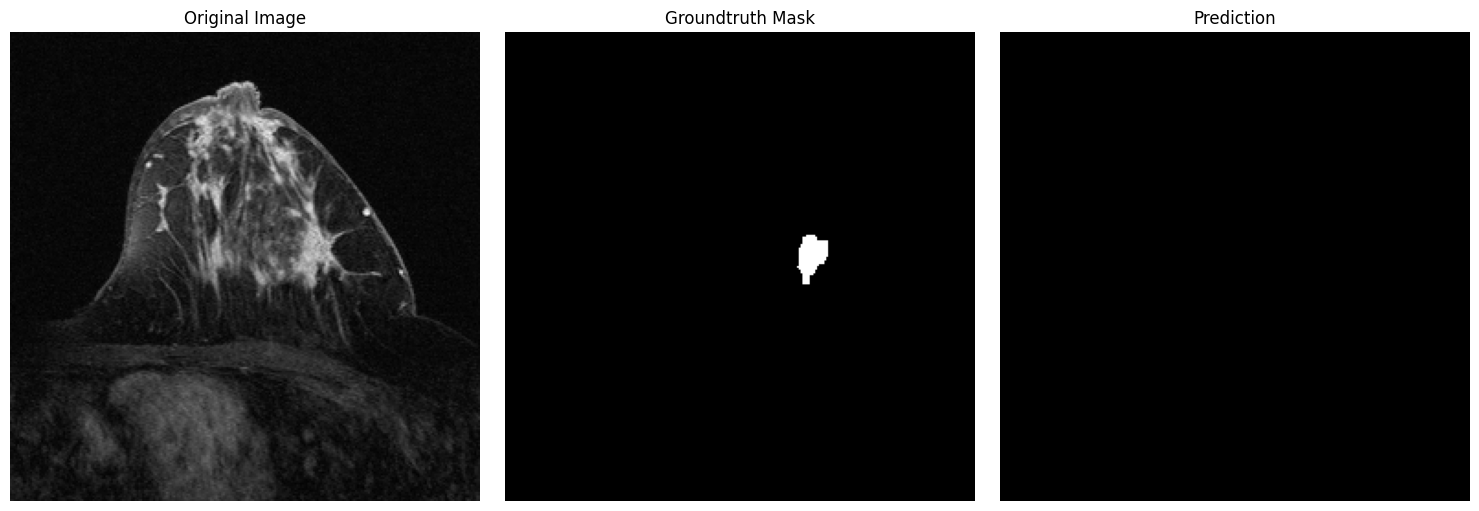

In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# 1. Hangi hastayı açmak istiyorsun?
# ===============================
case = "ispy1_1082"   # burayı istediğin zaman değiştirebilirsin

original_path = f"/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/imagesTs/{case}_0000.nii.gz"
gt_path       = f"/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/labelsTs/{case}.nii.gz"
pred_path     = f"/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions_attention_postprocessed_correct/{case}_postprocessed.nii.gz"

# ===============================
# 2. Verileri yükle
# ===============================
original_img = nib.load(original_path).get_fdata()
gt = nib.load(gt_path).get_fdata()
pred = nib.load(pred_path).get_fdata()

print("📌 Orijinal görüntü boyutu:", original_img.shape)

# ===============================
# 3. Slice'ı kullanıcıdan al
# ===============================
max_slice = original_img.shape[2] - 1
slice_idx = int(input(f"👉 Bir slice seç (0 - {max_slice} arası): "))

if slice_idx < 0 or slice_idx > max_slice:
    raise ValueError("❌ Geçersiz slice index!")

# ===============================
# 4. Görselleri hazırla
# ===============================
images = [
    original_img[:, :, slice_idx],
    gt[:, :, slice_idx],
    pred[:, :, slice_idx]
]
titles = ["Original Image", "Groundtruth Mask", "Prediction"]

# ===============================
# 5. Görselleri çiz
# ===============================
plt.figure(figsize=(15, 5))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i], fontsize=12)
    plt.axis("off")

plt.tight_layout()
plt.show()


Kritik Kontrol: checkpoint_best.pth ve Training Plans eşleşiyor mu?
Eğitim verileri ile test verilerinde aynı öodel mi kullanılıyor?

In [ ]:
# from nnunetv2.inference.predict_from_raw_data import nnUNetPredictor

# predictor = nnUNetPredictor()
# predictor.initialize_from_trained_model_folder(
#     model_training_output_dir="/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/nnUNetTrainer_Attention__nnUNetPlans__3d_fullres",
#     use_folds=("all",),
#     checkpoint_name="checkpoint_best.pth"
# )

# print("Model Loaded Successfully!")
# print("Network Architecture:", predictor.network.__class__)


Model Loaded Successfully!
Network Architecture: <class 'dynamic_network_architectures.architectures.unet.PlainConvUNet'>


Attention Patch Gerçekten Loaded mı?

MODEL TEST SIRASINDA ATTENTION KULLANILDI MI?

In [ ]:
# import inspect
# from nnunetv2.utilities.simple_conv_blocks import StackedConvBlocks

# source = inspect.getsource(StackedConvBlocks)
# print(source)


class StackedConvBlocks(nn.Module):
    def __init__(self,
                 num_convs: int,
                 conv_op: Type[_ConvNd],
                 input_channels: int,
                 output_channels: Union[int, List[int], Tuple[int, ...]],
                 kernel_size: Union[int, List[int], Tuple[int, ...]],
                 initial_stride: Union[int, List[int], Tuple[int, ...]],
                 conv_bias: bool = False,
                 norm_op: Union[None, Type[nn.Module]] = None,
                 norm_op_kwargs: dict = None,
                 dropout_op: Union[None, Type[_DropoutNd]] = None,
                 dropout_op_kwargs: dict = None,
                 nonlin: Union[None, Type[torch.nn.Module]] = None,
                 nonlin_kwargs: dict = None,
                 nonlin_first: bool = False
                 ):
        super().__init__()
        if not isinstance(output_channels, (tuple, list)):
            output_channels = [output_channels] * num_convs

        self.convs = 

In [ ]:
# import inspect
# import nnunetv2.utilities.simple_conv_blocks as scb

# print("📂 Kullanılan simple_conv_blocks.py dosyası:")
# print(scb.__file__)

# print("\n📄 StackedConvBlocks.forward gövdesi:")
# print(inspect.getsource(scb.StackedConvBlocks.forward))


📂 Kullanılan simple_conv_blocks.py dosyası:
/content/nnUNet/nnunetv2/utilities/simple_conv_blocks.py

📄 StackedConvBlocks.forward gövdesi:
    def forward(self, x):
        return self.convs(x)



kontrol attention uygulanmış mı

In [ ]:
# import torch
# import numpy as np

# # PyTorch güvenlik izinleri
# torch.serialization.add_safe_globals([np.core.multiarray.scalar])

# ckpt_path = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/nnUNetTrainer_Attention__nnUNetPlans__3d_fullres/fold_all/checkpoint_best.pth"

# # Güvenli şekilde yükle
# state = torch.load(ckpt_path, map_location="cpu", weights_only=False)

# print("📦 Anahtar sayısı:", len(state["network_weights"].keys()))

# # Attention var mı kontrol
# attention_keys = [
#     k for k in state["network_weights"].keys()
#     if "ca" in k.lower() or "attention" in k.lower()
# ]

# print("\n🔍 Attention ile ilgili key'ler:")
# for k in attention_keys:
#     print("   ", k)

# if len(attention_keys) == 0:
#     print("\n❌ Bu checkpoint'te ATTENTION yok.")
# else:
#     print("\n✅ BU CHECKPOINT ATTENTION KULLANIYOR!")


/tmp/ipython-input-729754147.py:5: DeprecationWarning: numpy.core is deprecated and has been renamed to numpy._core. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.multiarray.
  torch.serialization.add_safe_globals([np.core.multiarray.scalar])


📦 Anahtar sayısı: 292

🔍 Attention ile ilgili key'ler:

❌ Bu checkpoint'te ATTENTION yok.


Aşaıdakinin Görüntünün Çıkması için Gerekli Kodlar

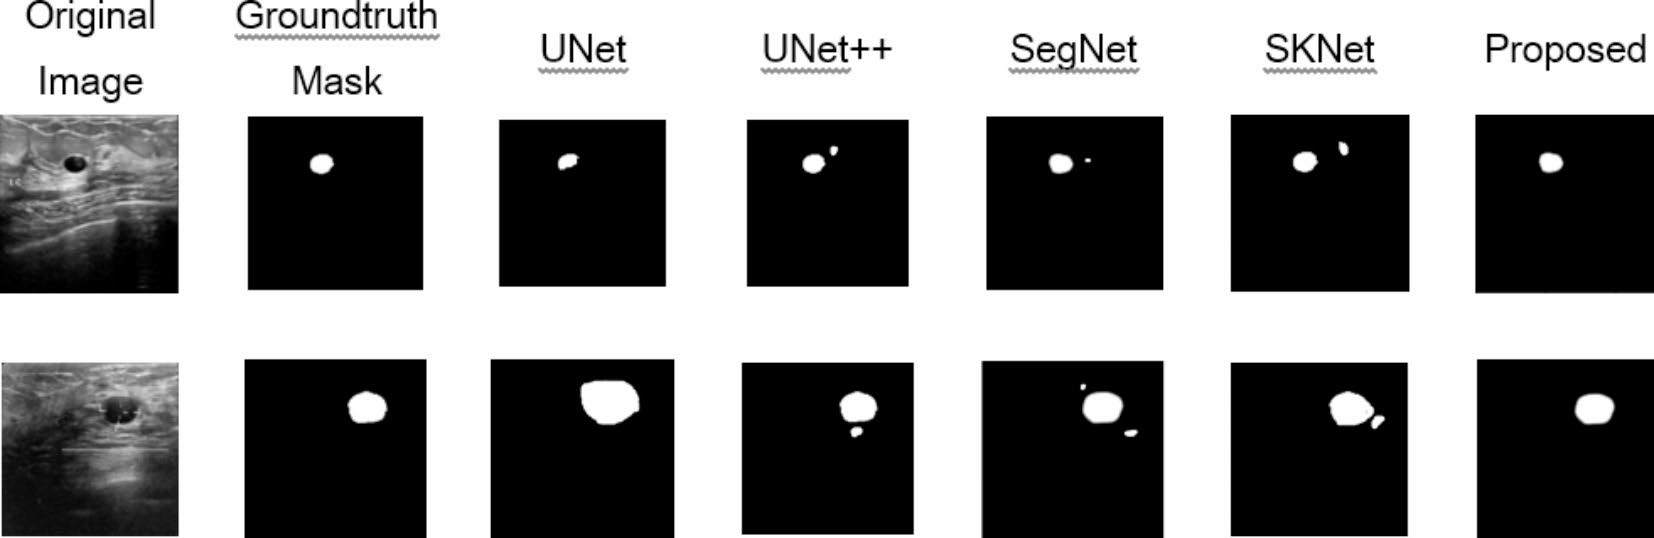

Aşağıdaki kod çalışmadı

In [ ]:
# import nibabel as nib
# import numpy as np
# import matplotlib.pyplot as plt

# # ==========================
# # 1. Dosya yollarını belirt
# # ==========================
# original_path   = "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/imagesTs/ispy1_1082_0000.nii.gz"
# gt_path         = "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/labelsTs/ispy1_1082.nii.gz"
# pred_path       = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions/ispy1_1082.nii.gz"

# # ==========================
# # 2. Dosyaları yüklev
# # ==========================
# original_img = nib.load(original_path).get_fdata()
# gt           = nib.load(gt_path).get_fdata()
# pred         = nib.load(pred_path).get_fdata()

# # ==========================
# # 3. Slice seçimi
# # ==========================
# # Orijinal görüntünün boyutunu yazdıralım
# print("Orijinal görüntü boyutları (x, y, z):", original_img.shape)

# # Kullanıcıdan slice seçimi (z ekseni üzerinden)
# slice_idx = int(input(f"Bir slice seç (0 - {original_img.shape[2]-1} arası): "))

# # ==========================
# # 4. Görselleri hazırla
# # ==========================
# images = [
#     original_img[:, :, slice_idx],
#     gt[:, :, slice_idx],
#     pred[:, :, slice_idx],
# ]

# titles = ["Original Image", "Groundtruth", "Prediction"]

# # ==========================
# # 5. Görselleştirme
# # ==========================
# plt.figure(figsize=(12, 4))
# for i in range(len(images)):
#     plt.subplot(1, len(images), i+1)
#     plt.imshow(images[i], cmap="gray")
#     plt.title(titles[i], fontsize=10)
#     plt.axis("off")

# plt.tight_layout()
# plt.show()


Orijinal görüntü boyutları (x, y, z): (256, 256, 64)
Bir slice seç (0 - 63 arası): 35
